# Dependency

In [1]:
import h5py
import os
import pickle

from tqdm import tqdm
from time import gmtime, strftime
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import RandomOverSampler

import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.decomposition import IncrementalPCA
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Reshape, 
    Dropout, Bidirectional
)
import tensorflow as tf
from tensorflow.keras import layers,Model
from tensorflow import keras
##

from sklearn.model_selection import KFold

import gc

import time
from sklearn.model_selection import KFold

#import import_test_ETC as load_data
import import_test as load_data
#import import_test as load_data
#import import_test_nine as load_data

# PARAM

In [2]:
DATA_LABEL=load_data.data_label()


MAXSEQ = 35
DATASET="cd_30"
DATA_TYPE = "rag_prostt5"
kind="all"
NUM_FEATURE = 1024

NUM_FILTER = 512
NUM_HIDDEN = 1000
BATCH_SIZE  = 1024
WINDOW_SIZES = [16,18,28,32]
lstm_units=128

NUM_CLASSES = 2
CLASS_NAMES = ['Negative','Positive']


EPOCHS      = 50

K_Fold = 5
VALIDATION_MODE="cross"
IMBALANCE="None"

In [3]:
"----------------------------------------------------------------------------------------------------"
# model fit batch funtion
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data, labels, batch_size):
        self.data = data
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.data))

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_data = [self.data[i] for i in batch_indexes]
        batch_labels = [self.labels[i] for i in batch_indexes]
        return np.array(batch_data), np.array(batch_labels)
    
"----------------------------------------------------------------------------------------------------"

'----------------------------------------------------------------------------------------------------'

# MCNN

In [4]:
class DeepScan(Model):

	def __init__(self,
                 input_shape=(MAXSEQ, NUM_FEATURE),
                 window_sizes=[3, 5, 7],
                 num_filters=64,
                 lstm_units=64,
                 num_hidden=128):
		super(DeepScan, self).__init__()

		self.input_layer = tf.keras.Input(shape=input_shape)

        # 針對不同 kernel_size 做多通道
		self.branches = []
		for w in window_sizes:
                
			branch = tf.keras.Sequential([
				layers.Conv1D(filters=num_filters,
                              kernel_size=w,
                              activation='relu',
                              padding="valid"
                              ),
				#layers.MaxPooling1D(pool_size=(MAXSEQ - w + 1),strides=(MAXSEQ),padding='same'),
				layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=False))
            ])
			self.branches.append(branch)

		self.dropout = layers.Dropout(0.9)
		self.fc1 = layers.Dense(num_hidden, activation='relu')
		self.fc2 = layers.Dense(NUM_CLASSES, activation='softmax')

        # 建構函式中先呼叫
		self.out = self.call(self.input_layer)

	def call(self, x, training=False):
		outs = []
		for branch in self.branches:
			y = branch(x, training=training)  # shape=(batch, 2*lstm_units)
			outs.append(y)

		x_cat = tf.concat(outs, axis=1)  # (batch, len(window_sizes)*2*lstm_units)
		x_cat = self.dropout(x_cat, training=training)
		x_cat = self.fc1(x_cat)
		x_cat = self.fc2(x_cat)
		return x_cat

# Main

In [5]:
# Example usage:
x_train,y_train,x_test,y_test= load_data.MCNN_data_load(DATA_TYPE,kind)

(236,)
(245,)
(59,)
(62,)


In [6]:
x_train = np.squeeze(x_train, axis=1) 
x_test  = np.squeeze(x_test, axis=1)

In [7]:
def model_test(model, x_test, y_test):

    #print(x_test.shape)
    pred_test = model.predict(x_test)
    #print(pred_test)
    #print(x_test)
    fpr, tpr, thresholds = roc_curve(y_test[:,1], pred_test[:, 1])
    ROCAUC = metrics.auc(fpr, tpr)
    #tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None)

    precisions, recalls, threshold = precision_recall_curve(y_test[:,1], pred_test[:, 1])
    PRAUC = metrics.auc(recalls, precisions)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=ROCAUC, estimator_name='mCNN')
    display.plot()
    plt.savefig("ROC_33.png",dpi=600)
    disp2 =metrics.PrecisionRecallDisplay(precision= precisions, recall=recalls,average_precision=PRAUC,estimator_name='mCNN')
    disp2.plot()
    # calculate the g-mean for each threshold
    gmeans = np.sqrt(tpr * (1-fpr))
    # locate the index of the largest g-mean
    ix = np.argmax(gmeans)
    print(f'Best Threshold={thresholds[ix]}, G-Mean={gmeans[ix]}')
    threshold = thresholds[ix]

    y_pred = (pred_test[:, 1] >= threshold).astype(int)
    #print(y_pred)

    TN, FP, FN, TP =  metrics.confusion_matrix(y_test[0:][:,1], y_pred).ravel()

    Sens = TP/(TP+FN) if TP+FN > 0 else 0.0
    Spec = TN/(FP+TN) if FP+TN > 0 else 0.0
    Acc = (TP+TN)/(TP+FP+TN+FN)
    MCC = (TP*TN-FP*FN)/math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) if TP+FP > 0 and FP+TN > 0 and TP+FN and TN+FN else 0.0
    F1 = 2*TP/(2*TP+FP+FN)
    Prec=TP/(TP+FP)
    Recall=TP/(TP+FN)
    print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}, Sens={Sens:.4f}, Spec={Spec:.4f}, Acc={Acc:.4f}, MCC={MCC:.4f}, ROCAUC={ROCAUC:.4f}, F1={F1:.4f}, Prec={Prec:.4f}, Recall={Recall:.4f}, PRAUC={PRAUC:.4f}\n')
    #SAVEROC(fpr,tpr,ROCAUC)
    return TP,FP,TN,FN,Sens,Spec,Acc,MCC,ROCAUC,F1,Prec,Recall,PRAUC

In [8]:
def model_test_1(model, x_test, y_test):

    #print(x_test.shape)
    pred_test = model.predict(x_test)
    #print(pred_test)
    #print(x_test)
    fpr, tpr, thresholds = roc_curve(y_test[:,1], pred_test[:, 1])
    ROCAUC = metrics.auc(fpr, tpr)
    #tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None)

    precisions, recalls, threshold = precision_recall_curve(y_test[:,1], pred_test[:, 1])
    PRAUC = metrics.auc(recalls, precisions)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=ROCAUC, estimator_name='mCNN')
    display.plot()
    plt.savefig("ROC_33.png",dpi=600)
    disp2 =metrics.PrecisionRecallDisplay(precision= precisions, recall=recalls,average_precision=PRAUC,estimator_name='mCNN')
    disp2.plot()
    # calculate the g-mean for each threshold
    gmeans = np.sqrt(tpr * (1-fpr))
    # locate the index of the largest g-mean
    ix = np.argmax(gmeans)
    print(f'Best Threshold={thresholds[ix]*0.1}, G-Mean={gmeans[ix]}')
    threshold = 0.08029785752296448/10

    y_pred = (pred_test[:, 1] >= threshold).astype(int)
    #print(y_pred)

    TN, FP, FN, TP =  metrics.confusion_matrix(y_test[0:][:,1], y_pred).ravel()

    Sens = TP/(TP+FN) if TP+FN > 0 else 0.0
    Spec = TN/(FP+TN) if FP+TN > 0 else 0.0
    Acc = (TP+TN)/(TP+FP+TN+FN)
    MCC = (TP*TN-FP*FN)/math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) if TP+FP > 0 and FP+TN > 0 and TP+FN and TN+FN else 0.0
    F1 = 2*TP/(2*TP+FP+FN)
    Prec=TP/(TP+FP)
    Recall=TP/(TP+FN)
    print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}, Sens={Sens:.4f}, Spec={Spec:.4f}, Acc={Acc:.4f}, MCC={MCC:.4f}, ROCAUC={ROCAUC:.4f}, F1={F1:.4f}, Prec={Prec:.4f}, Recall={Recall:.4f}, PRAUC={PRAUC:.4f}\n')
    #SAVEROC(fpr,tpr,ROCAUC)
    return TP,FP,TN,FN,Sens,Spec,Acc,MCC,ROCAUC,F1,Prec,Recall,PRAUC

1 / 5 

(384, 35, 1024)
(97, 35, 1024)
(384, 2)
(97, 2)
Model: "deep_scan"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 128)               8684544   
                                                                 
 sequential_1 (Sequential)   (None, 128)               9733120   
                                                                 
 sequential_2 (Sequential)   (None, 128)               14976000  
                                                                 
 sequential_3 (Sequential)   (None, 128)               17073152  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 1000)              513000    
                                                                 
 

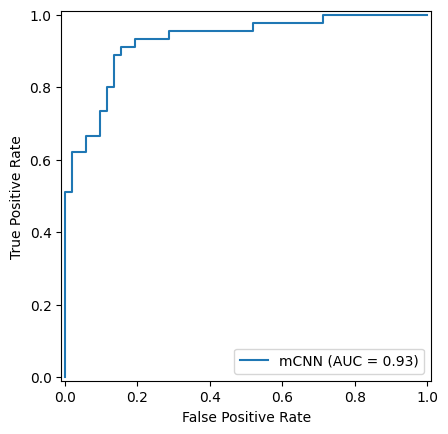

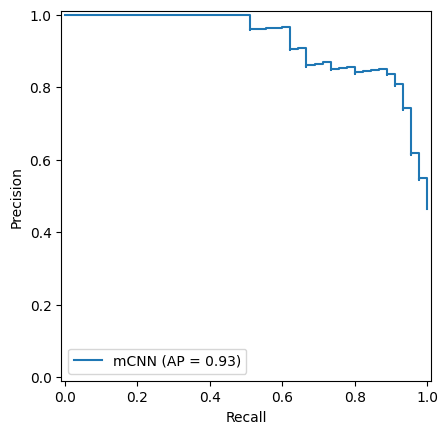

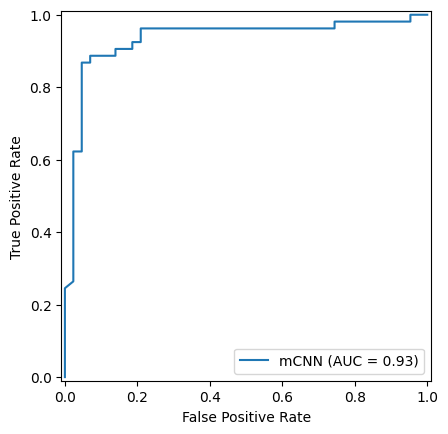

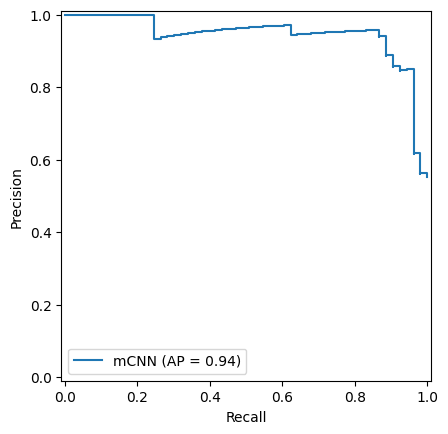

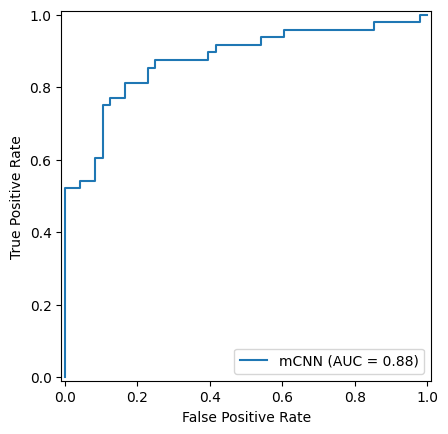

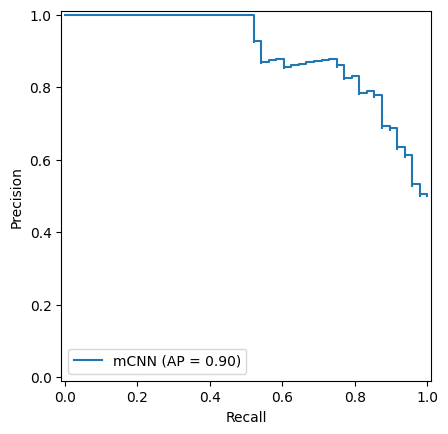

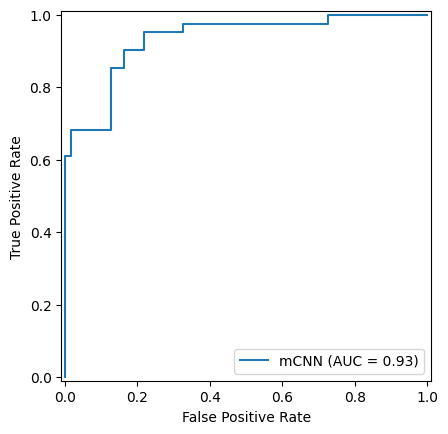

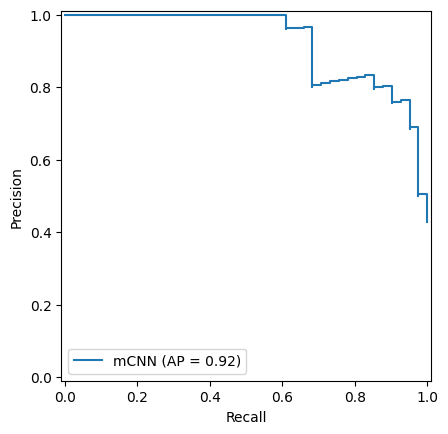

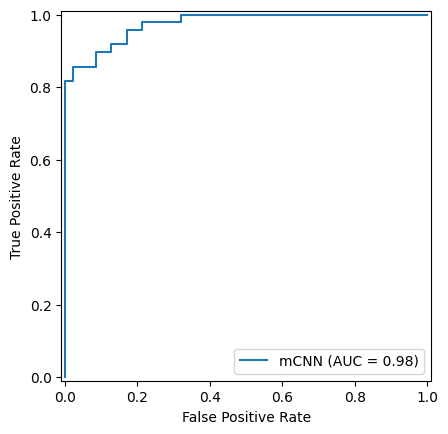

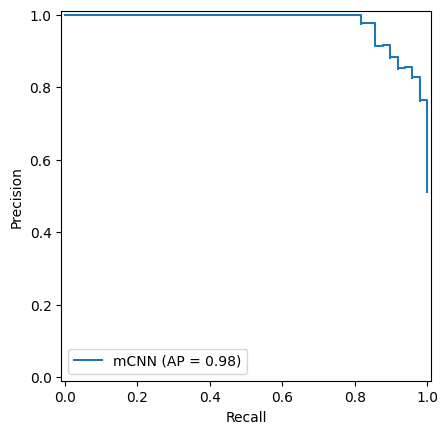

In [9]:
if(VALIDATION_MODE=="cross"):
	
	kfold = KFold(n_splits = K_Fold, shuffle = True, random_state = 2)
	results=[]
	i=1
	for train_index, test_index in kfold.split(x_train):
		print(i,"/",K_Fold,'\n')
		# 取得訓練和測試數據
		X_train, X_test = x_train[train_index], x_train[test_index]
		Y_train, Y_test = y_train[train_index], y_train[test_index]
		
		print(X_train.shape)
		print(X_test.shape)
		print(Y_train.shape)
		print(Y_test.shape)
		generator = DataGenerator(X_train, Y_train, batch_size=BATCH_SIZE)
		# 重新建模
		model = DeepScan(
		num_filters=NUM_FILTER,
			num_hidden=NUM_HIDDEN,
			window_sizes=WINDOW_SIZES)
		model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
		model.build(input_shape=X_train.shape)
		model.summary()
		# 在測試數據上評估模型
		history=model.fit(
			generator,
			epochs=EPOCHS,
			callbacks=[tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10)],
			verbose=1,
			shuffle=True
		)
		TP,FP,TN,FN,Sens,Spec,Acc,MCC,ROCAUC,F1,Prec,Recall,PRAUC = model_test(model, X_test, Y_test)
		results.append([TP,FP,TN,FN,Sens,Spec,Acc,MCC,ROCAUC,F1,Prec,Recall,PRAUC])
		i+=1
		
		del X_train
		del X_test
		del Y_train
		del Y_test
		gc.collect()
		
	mean_results = np.mean(results, axis=0)
	print(f'TP={mean_results[0]:.4}, FP={mean_results[1]:.4}, TN={mean_results[2]:.4}, FN={mean_results[3]:.4}, Sens={mean_results[4]:.4}, Spec={mean_results[5]:.4}, Acc={mean_results[6]:.4},MCC={mean_results[7]:.4},ROCAUC={mean_results[8]:.4},F1={mean_results[9]:.4},Prec={mean_results[10]:.4},Recall={mean_results[11]:.4},PRAUC={mean_results[12]:.4}\n')

In [10]:
if(VALIDATION_MODE=="independent"):
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)
    model = DeepScan(
    	num_filters=NUM_FILTER,
    	num_hidden=NUM_HIDDEN,
    	window_sizes=WINDOW_SIZES)
    model.compile(optimizer='adam', loss='mse')#, metrics=['accuracy']
    model.build(input_shape=x_train.shape)
    model.summary()
    callback = EarlyStopping(monitor="loss", patience=10, verbose=1, mode="auto")
    model.fit(
    	generator,
    	epochs=EPOCHS,
    	shuffle=True,
        callbacks=[callback]
    )
    TP,FP,TN,FN,Sens,Spec,Acc,MCC,ROCAUC,F1,Prec,Recall,PRAUC = model_test(model, x_test, y_test)